<div style="text-align:center; border-radius:20px; padding:25px; color:white; margin:0; font-family:sans-serif; background:#1b002a; box-shadow:0px 6px 18px rgba(0,0,0,0.35); margin-bottom:1em;">
          <div style="font-size:200%; color:#FEE100; font-weight:700;">
            student-dropout-prediction-dataset-ETL,EDA,Visualize
          </div>
        </div>
        

![Dataset Image](https://holosen.net/api/file/6c695ec8-213d-42c3-9335-242571a533ba)


In [1]:
import os
main_csv_local_path = 'student_dropout_dataset_v3.csv'
DATA_DIR = ''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == main_csv_local_path:
            DATA_DIR = os.path.join(dirname, filename)
            print(DATA_DIR)


/kaggle/input/datasets/meharshanali/student-dropout-prediction-dataset/student_dropout_dataset_v3.csv


--- Loading Dataset: meharshanali/student-dropout-prediction-dataset ---
Column Validation Successful: All expected columns found.

--- Data Audit Overview ---
Shape: (10000, 19)
Duplicates: 0

Missing Values Audit:
                       Null Count  Null %  Non-Null Count
Parental_Education            511    5.11            9489
Family_Income                 500    5.00            9500
Stress_Index                  500    5.00            9500
Study_Hours_per_Day           500    5.00            9500
Gender                          0    0.00           10000
Student_ID                      0    0.00           10000
Age                             0    0.00           10000
Assignment_Delay_Days           0    0.00           10000
Travel_Time_Minutes             0    0.00           10000
Internet_Access                 0    0.00           10000

Stability Audit (Numeric):

--- Outlier Audit (IQR) ---
 - Age: 33 outliers (0.33%)
 - Family_Income: 683 outliers (6.83%)
 - Study_Hours_per_Day

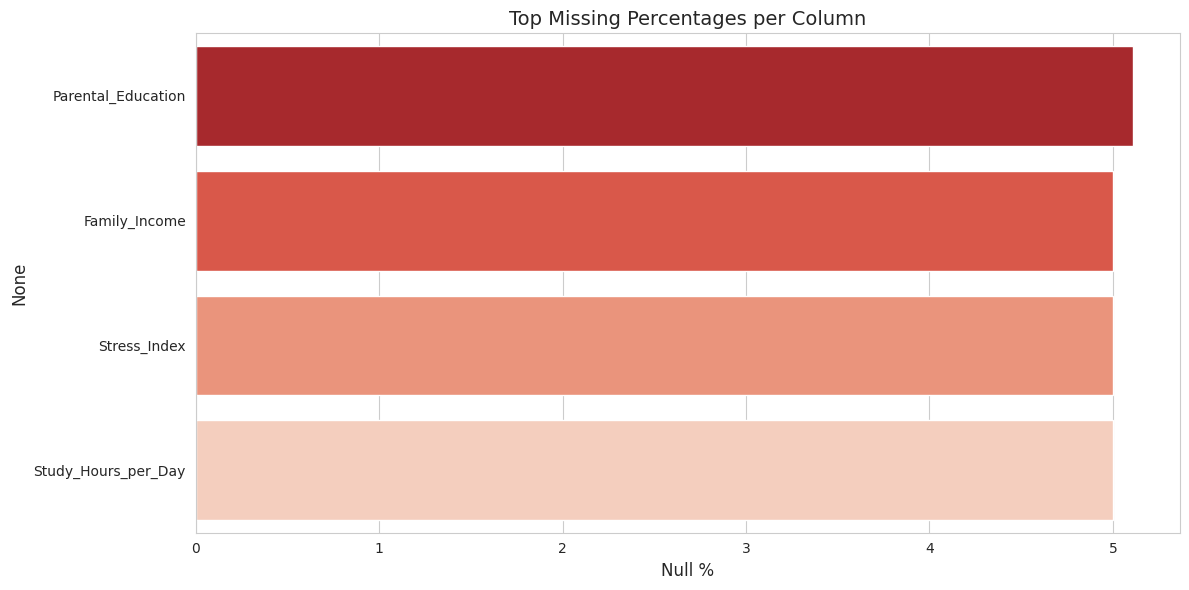

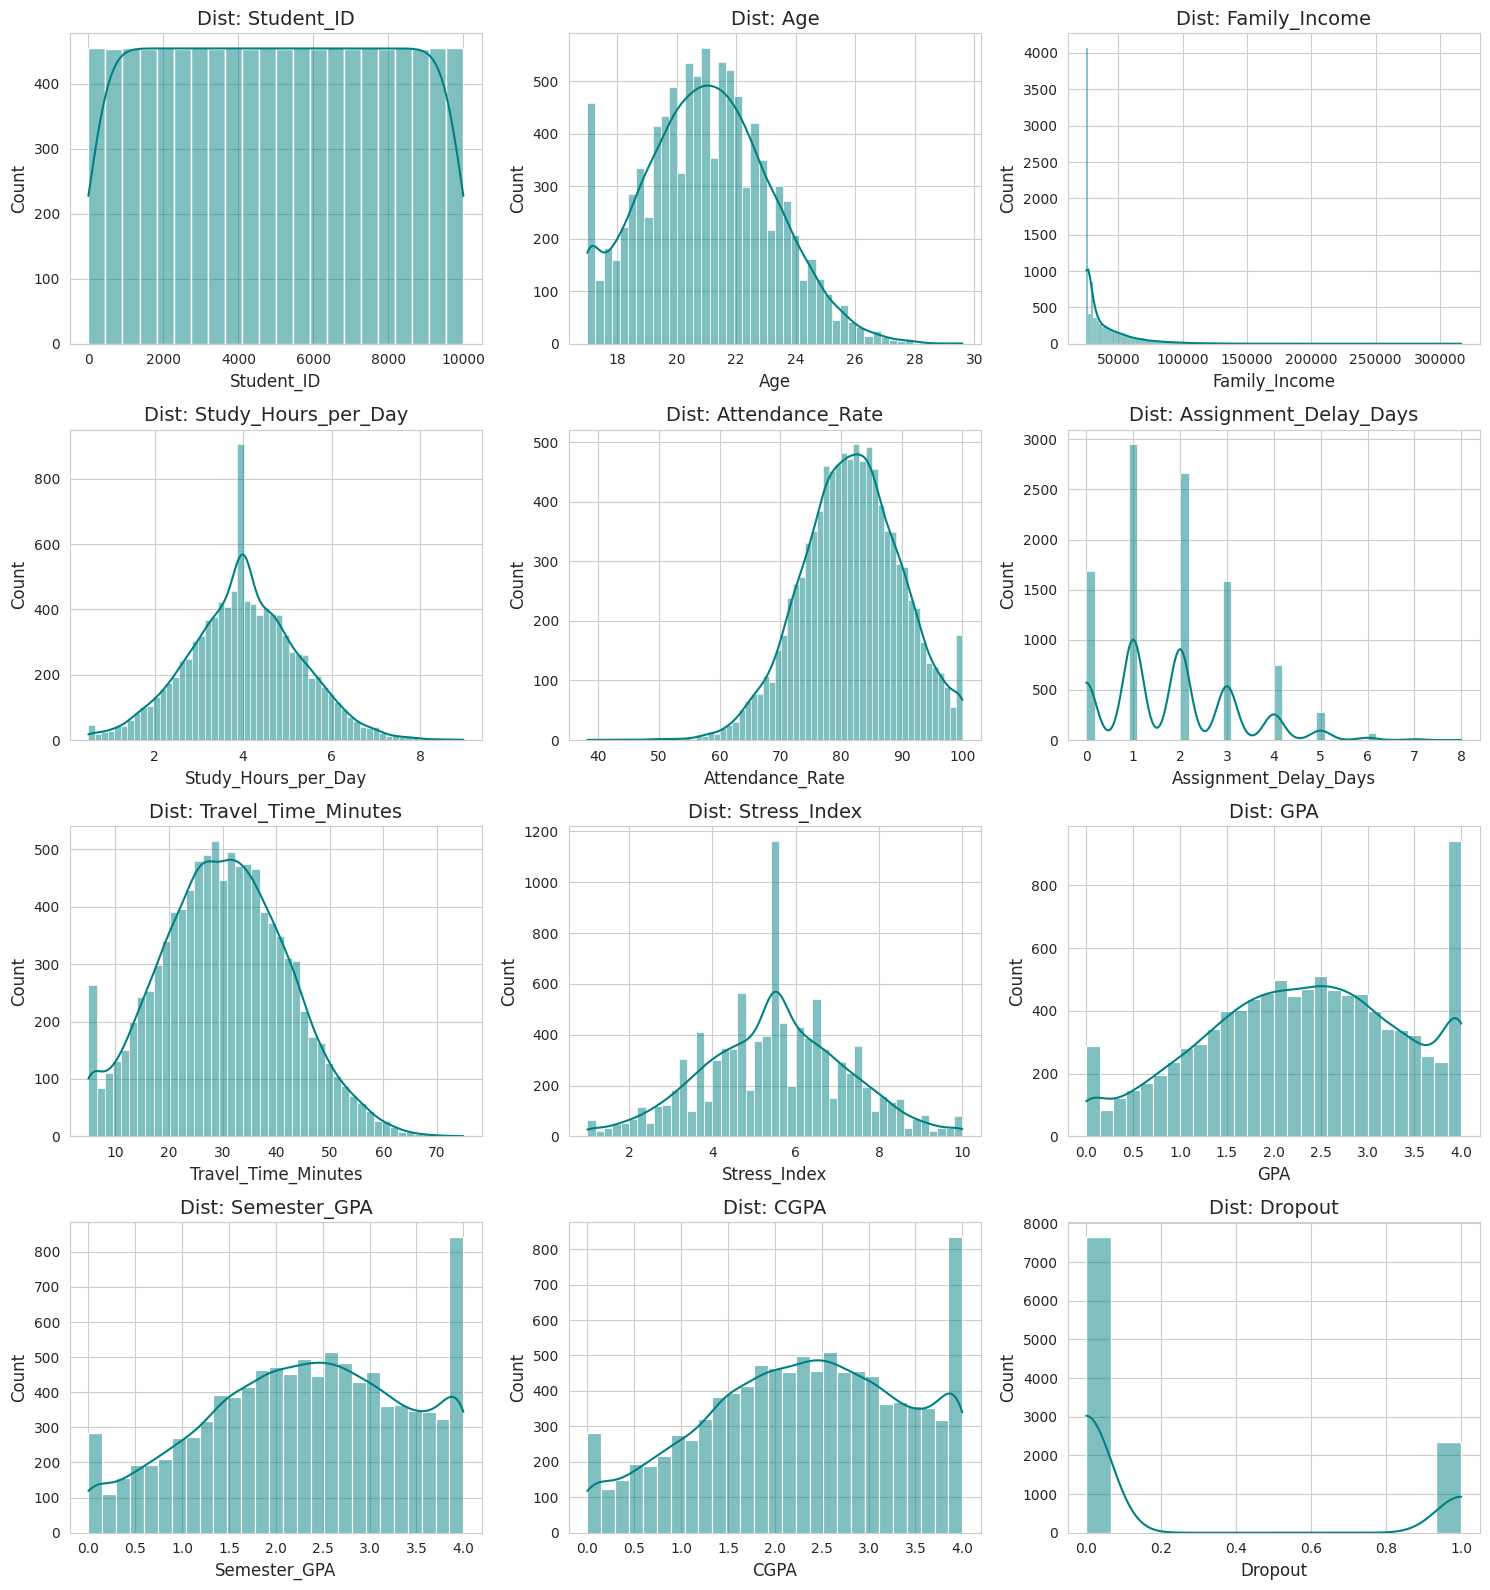

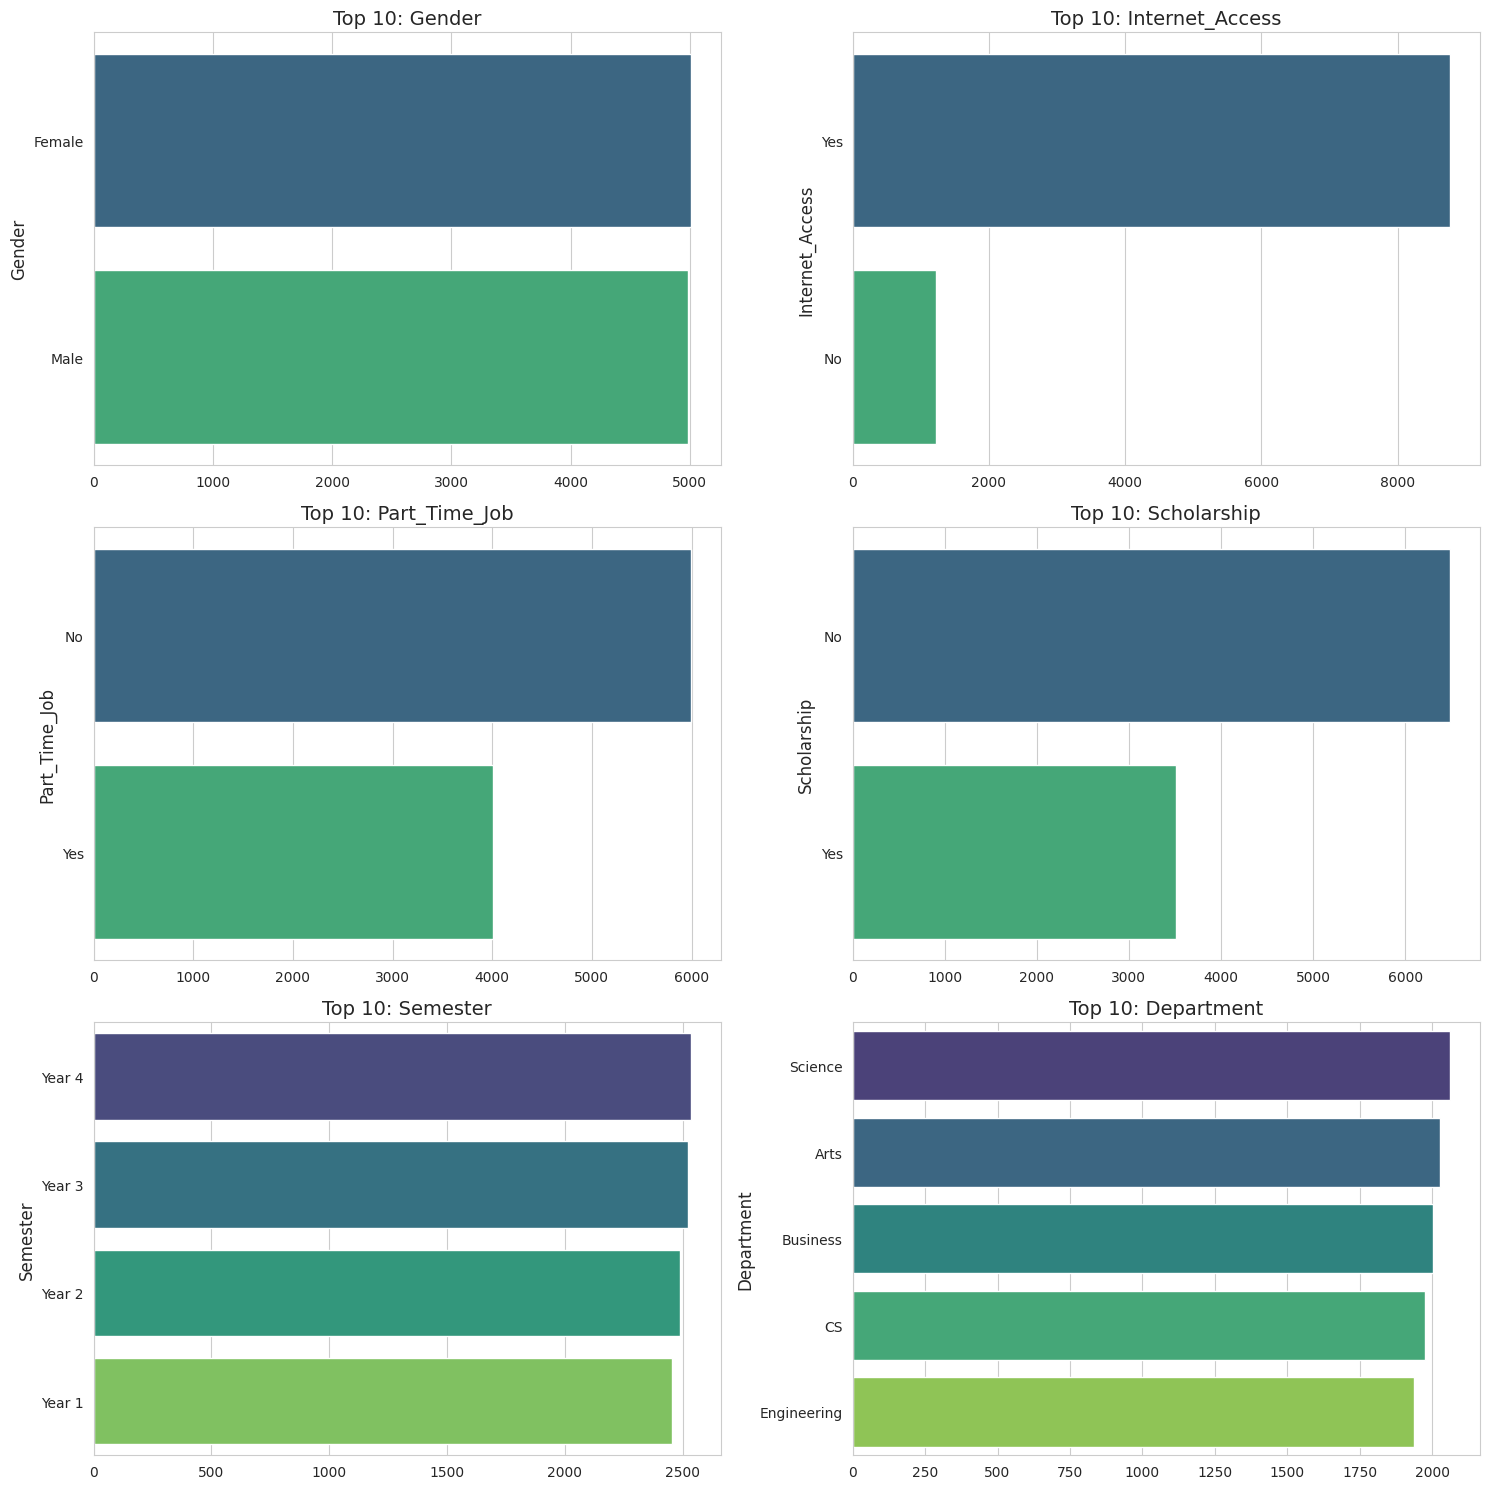

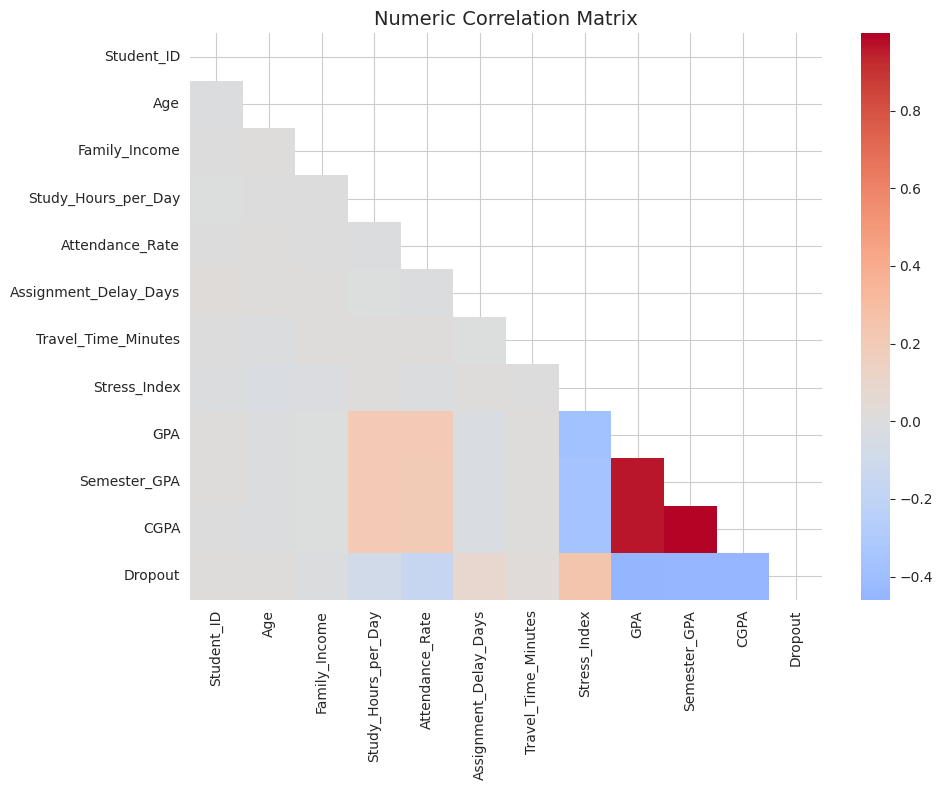

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

# ==========================================
# A) Imports + Global Config
# ==========================================
warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Optional Inputs provided by user
DATASET_NAME = "meharshanali/student-dropout-prediction-dataset"
EXACT_COLUMNS = [
    "Student_ID", "Age", "Gender", "Family_Income", "Internet_Access", 
    "Study_Hours_per_Day", "Attendance_Rate", "Assignment_Delay_Days", 
    "Travel_Time_Minutes", "Part_Time_Job", "Scholarship", "Stress_Index", 
    "GPA", "Semester_GPA", "CGPA", "Semester", "Department", 
    "Parental_Education", "Dropout"
]
TARGET_COL = "Dropout"

# ==========================================
# Helper Functions
# ==========================================

def safe_read_csv(path):
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

def audit_missingness(df):
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100
    audit = pd.DataFrame({
        'Null Count': null_counts,
        'Null %': null_pct,
        'Non-Null Count': df.notnull().sum()
    }).sort_values('Null Count', ascending=False)
    return audit

def detect_column_types(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    datetime_cols = []
    
    # Simple heuristic for potential dates in object columns
    for col in categorical_cols:
        sample = df[col].dropna().head(10).astype(str)
        if any(sample.str.contains(r'\d{4}-\d{2}-\d{2}|\d{2}/\d{2}/\d{4}')):
            datetime_cols.append(col)
            
    return numeric_cols, categorical_cols, datetime_cols

def safe_to_numeric(series):
    return pd.to_numeric(series, errors='coerce')

def safe_to_datetime(series):
    try:
        return pd.to_datetime(series, errors='coerce')
    except:
        return series

def get_outlier_info(series):
    if series.isnull().all() or not np.issubdtype(series.dtype, np.number):
        return 0, 0
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), (len(outliers) / len(series)) * 100

# ==========================================
# B) Load + Validate
# ==========================================
print(f"--- Loading Dataset: {DATASET_NAME} ---")
df = safe_read_csv(DATA_DIR)

if df is not None:
    actual_cols = df.columns.tolist()
    missing_expected = [c for c in EXACT_COLUMNS if c not in actual_cols]
    extra_cols = [c for c in actual_cols if c not in EXACT_COLUMNS]
    
    if missing_expected or extra_cols:
        print("Column Mismatch Detected:")
        if missing_expected: print(f" - Missing from CSV: {missing_expected}")
        if extra_cols: print(f" - Extra in CSV: {extra_cols}")
    else:
        print("Column Validation Successful: All expected columns found.")

# ==========================================
# C) Data Audit
# ==========================================
    print("\n--- Data Audit Overview ---")
    print(f"Shape: {df.shape}")
    print(f"Duplicates: {df.duplicated().sum()}")
    print("\nMissing Values Audit:")
    print(audit_missingness(df).head(10))

    numeric_cols, categorical_cols, potential_dates = detect_column_types(df)
    
    print("\nStability Audit (Numeric):")
    for col in numeric_cols:
        inf_count = np.isinf(df[col]).sum()
        std_val = df[col].std()
        if inf_count > 0 or std_val < 0.0001:
            print(f" - {col}: infs={inf_count}, low_variance={std_val:.4f}")

# ==========================================
# D) ETL (Safe + Reversible)
# ==========================================
    df_clean = df.copy()

    # Whitespace + Missing Tokens
    for col in categorical_cols:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].str.strip()
    
    df_clean.replace(["", "NA", "N/A", "null", "None", "NULL"], np.nan, inplace=True)

    # Conversion logic
    for col in categorical_cols:
        # Check if it should be numeric
        sample = df_clean[col].dropna().head(20).astype(str)
        if all(sample.str.match(r'^-?\d*\.?\d*$')):
            df_clean[col] = safe_to_numeric(df_clean[col])
            
    # Re-detect after conversion
    numeric_cols, categorical_cols, potential_dates = detect_column_types(df_clean)
    
    # Missing value handling with indicators
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            df_clean[f"{col}__was_missing"] = df_clean[col].isnull().astype(int)
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            
    for col in categorical_cols:
        if df_clean[col].isnull().any():
            df_clean[f"{col}__was_missing"] = df_clean[col].isnull().astype(int)
            df_clean[col] = df_clean[col].fillna("Missing")

    # Drop duplicates
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates(keep='first')
    removed_dupes = initial_rows - len(df_clean)

    # Outlier Analysis & Winsorization
    print("\n--- Outlier Audit (IQR) ---")
    for col in numeric_cols:
        count, rate = get_outlier_info(df_clean[col])
        if rate > 0:
            print(f" - {col}: {count} outliers ({rate:.2f}%)")
            lower_q = df_clean[col].quantile(0.01)
            upper_q = df_clean[col].quantile(0.99)
            df_clean[f"{col}__winsor"] = df_clean[col].clip(lower_q, upper_q)

# ==========================================
# E) EDA (Deeper + Kaggle-safe)
# ==========================================
    print("\n--- Numeric Distribution Summary ---")
    desc = df_clean[numeric_cols].describe().T
    desc['skew'] = df_clean[numeric_cols].skew()
    desc['kurtosis'] = df_clean[numeric_cols].kurtosis()
    print(desc)

    print("\n--- Correlation Analysis ---")
    if len(numeric_cols) >= 2:
        corr_matrix = df_clean[numeric_cols].corr(method='pearson')
        # High correlation detection
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [(column, row) for column in upper.columns for row in upper.index if abs(upper[column][row]) > 0.85]
        if high_corr:
            print("Highly correlated pairs (|r| > 0.85):")
            for pair in high_corr: print(f" - {pair[0]} & {pair[1]}: {corr_matrix.loc[pair[1], pair[0]]:.2f}")

    if TARGET_COL in df_clean.columns:
        print(f"\n--- Target-Aware Analysis ({TARGET_COL}) ---")
        if df_clean[TARGET_COL].dtype in [np.number] and df_clean[TARGET_COL].nunique() > 10:
            # Numeric Target
            target_corr = df_clean[numeric_cols].corrwith(df_clean[TARGET_COL]).sort_values(ascending=False)
            print("Correlations with Target:")
            print(target_corr.head(10))
        else:
            # Categorical/Discrete Target
            print(f"Target Distribution:\n{df_clean[TARGET_COL].value_counts(normalize=True)}")

# ==========================================
# F) Visualization
# ==========================================
    sns.set_style("whitegrid")

    # 1. Missingness
    null_audit = audit_missingness(df)
    if null_audit['Null Count'].sum() > 0:
        plt.figure()
        top_null = null_audit[null_audit['Null Count'] > 0].head(30)
        sns.barplot(x=top_null['Null %'], y=top_null.index, hue=top_null.index, palette='Reds_r', legend=False)
        plt.title("Top Missing Percentages per Column")
        plt.tight_layout()
        plt.savefig('missingness_chart.png')

    # 2. Distributions (Histograms)
    plot_num = min(len(numeric_cols), 12)
    if plot_num > 0:
        fig, axes = plt.subplots(int(np.ceil(plot_num/3)), 3, figsize=(15, 4 * int(np.ceil(plot_num/3))))
        axes = axes.flatten()
        for i, col in enumerate(numeric_cols[:plot_num]):
            sns.histplot(df_clean[col], kde=True, ax=axes[i], color='teal')
            axes[i].set_title(f'Dist: {col}')
        for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
        plt.tight_layout()
        plt.savefig('numeric_distributions.png')

    # 3. Categorical Counts
    plot_cat = min(len(categorical_cols), 6)
    if plot_cat > 0:
        fig, axes = plt.subplots(int(np.ceil(plot_cat/2)), 2, figsize=(15, 5 * int(np.ceil(plot_cat/2))))
        axes = axes.flatten()
        for i, col in enumerate(categorical_cols[:plot_cat]):
            vc = df_clean[col].value_counts().head(10)
            sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette='viridis', ax=axes[i], legend=False)
            axes[i].set_title(f'Top 10: {col}')
        for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
        plt.tight_layout()
        plt.savefig('categorical_counts.png')

    # 4. Correlation Heatmap
    if len(numeric_cols) >= 2:
        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0)
        plt.title("Numeric Correlation Matrix")
        plt.tight_layout()
        plt.savefig('correlation_heatmap.png')

# ==========================================
# G) Lightweight Feature Engineering
# ==========================================
    # Text length features
    for col in categorical_cols:
        if df_clean[col].dtype == 'object':
            # Safe length calculation
            df_clean[f"{col}__len"] = df_clean[col].astype(str).apply(len)
            # Word count
            df_clean[f"{col}__words"] = df_clean[col].astype(str).apply(lambda x: len(x.split()))

# ==========================================
# H) Final Artifact Output
# ==========================================
    print("\n" + "="*40)
    print("FINAL DATA QUALITY SUMMARY")
    print("="*40)
    print(f"Original Shape: {df.shape}")
    print(f"Cleaned Shape:  {df_clean.shape}")
    print(f"Duplicates Removed: {removed_dupes}")
    print(f"Numeric Columns: {len(numeric_cols)}")
    print(f"Categorical Columns: {len(categorical_cols)}")
    print(f"Total Missing Values Remaining: {df_clean.isnull().sum().sum()}")
    print("\nFirst 5 rows of df_clean:")
    print(df_clean.head())

else:
    print("Pipeline terminated: Dataset could not be loaded.")
